## Trie/Prefix Tree

A Trie is a tree-like data structure used to efficiently store and search strings, especially when dealing with:

✅ Prefix searches

✅ Autocomplete systems

✅ Spell checkers

✅ Dictionary lookups

Instead of storing whole words like a hash table, a trie stores characters step by step.

#### Key characteristics:

1. Each node represents a single character
2. Paths from root to nodes form words
3. Common prefixes share the same path

##### Visual example for words: "cat", "car", "dog", "door"

        root
       /    \
      c      d
      |      |
      a      o
     / \     |
    t   r    g/o
              |
              r

##### New set of words
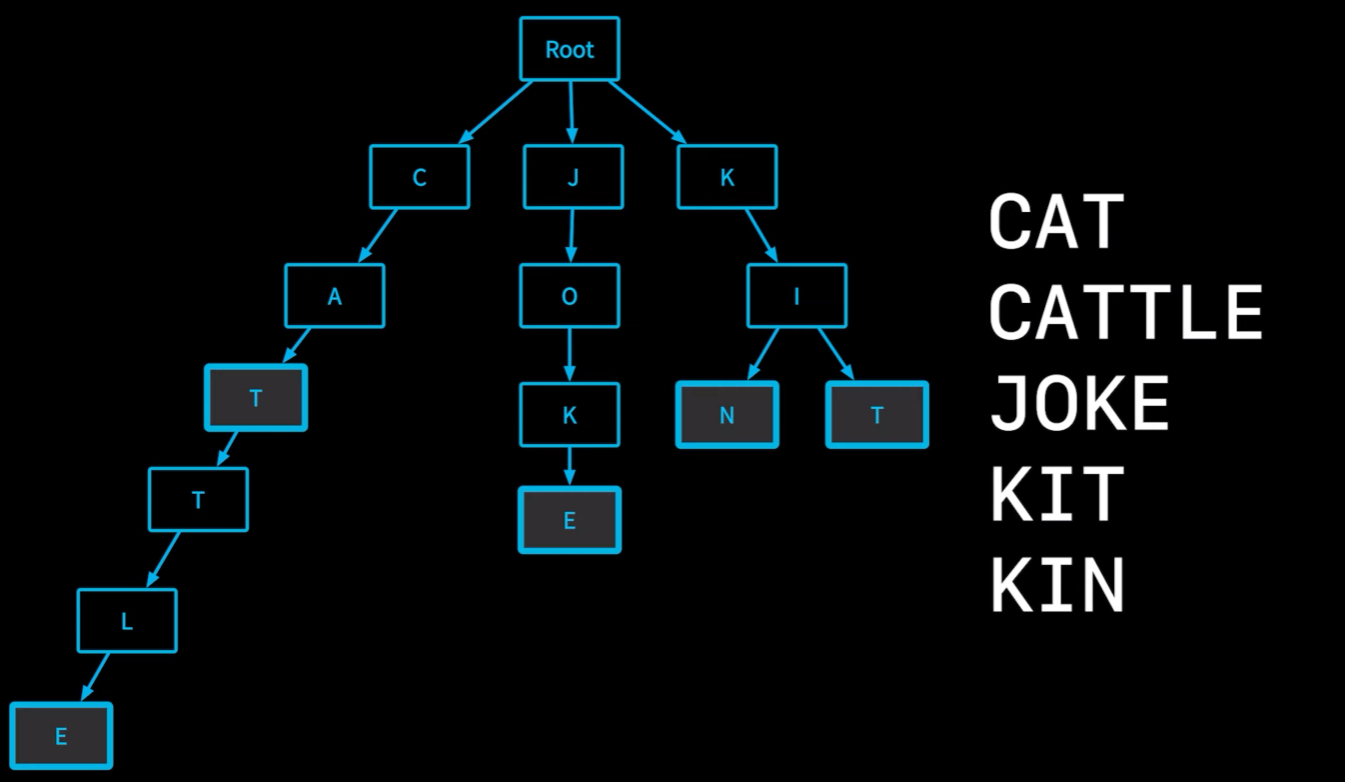

In the above diagram:
1. We store the words : Cat, Cattle, Joke, Kit, Kin.
2. The greyed node represents end of the string so we need to mark them else we will never know when is the end of each word

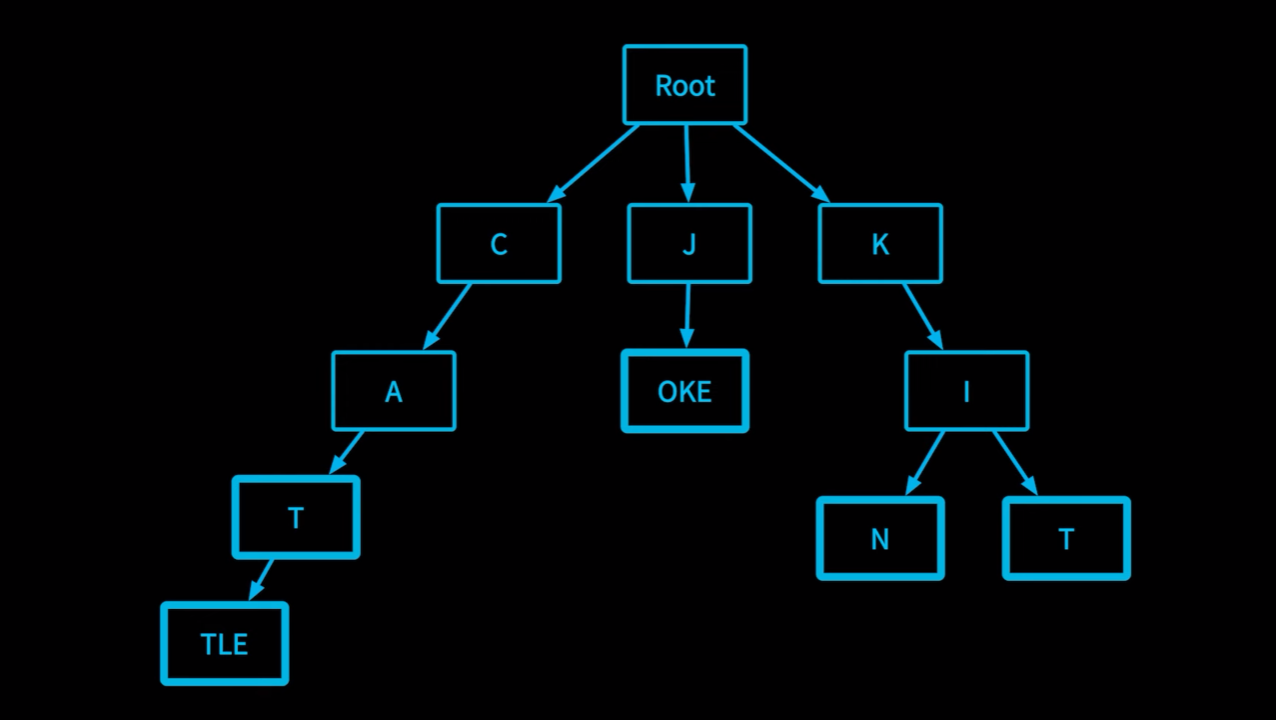

In the above diagram:
1. You see nodes represented as substrings
2. This representation produces smaller trees but also complicated so for simplicity we will stcik to one character per node

#### Time Complexity
OperationTime   |   Complexity

Insert          |   O(m) where m = word length

Search          |   O(m)

Delete          |   O(m)

Prefix Search   |   O(p) where p = prefix length

Space Complexity: O(ALPHABET_SIZE × N × M) in worst case, where N is number of words and M is average length.

### Implimentation

In [7]:
class TrieNode:
    """Represents a single node in the Trie"""
    def __init__(self):
        # Dictionary to store child nodes (character -> TrieNode)
        self.children = {}

        # Marks if this node represents the end of a word
        self.is_end_of_word = False

        # Optional: store the complete word at end nodes (useful for autocomplete)
        self.word = None
        
        # Optional: count of words passing through this node
        self.word_count = 0

In [8]:
class Trie:
    """Trie data structure for efficient string operations"""
    
    def __init__(self):
        self.root = TrieNode()

    # ==================== INSERTION ====================
    def insert(self, word):
        """
        Insert a word into the trie.
        Time: O(m) where m is the length of the word
        Space: O(m) in worst case
        """
        node = self.root
        
        for char in word:
            # If character doesn't exist, create new node
            if char not in node.children:
                node.children[char] = TrieNode()
            
            # Move to the child node
            node = node.children[char]
            node.word_count += 1
        
        # Mark the end of the word
        node.is_end_of_word = True
        node.word = word

    # ==================== SEARCH ====================
    def search(self, word):
        """
        Search for an exact word in the trie.
        Returns True if word exists, False otherwise.
        Time: O(m)
        """
        node = self._find_node(word)
        # Word exists only if we reach a node AND it's marked as end of word
        return node is not None and node.is_end_of_word
    
    def _find_node(self, prefix):
        """Helper method to find the node representing a prefix"""
        node = self.root
        
        for char in prefix:
            if char not in node.children:
                return None
            node = node.children[char]
        
        return node
    
    # ==================== PREFIX SEARCH ====================
    def starts_with(self, prefix):
        """
        Check if there's any word starting with the given prefix.
        Time: O(p) where p is the length of prefix
        """
        return self._find_node(prefix) is not None
    
    # ==================== AUTOCOMPLETE ====================
    def autocomplete(self, prefix, limit=10):
        """
        Find all words starting with the given prefix.
        Returns a list of words.
        Time: O(p + n) where p is prefix length, n is number of results
        """
        results = []
        node = self._find_node(prefix)
        
        if node is None:
            return results
        
        # DFS to find all words from this node
        self._dfs_words(node, results, limit)
        return results
    
    def _dfs_words(self, node, results, limit):
        """Helper method to collect all words using DFS"""
        if len(results) >= limit:
            return
        
        if node.is_end_of_word:
            results.append(node.word)
        
        for char in sorted(node.children.keys()):
            self._dfs_words(node.children[char], results, limit)

    # ==================== DELETE ====================
    def delete(self, word):
        """
        Delete a word from the trie.
        Returns True if word was deleted, False if word didn't exist.
        Time: O(m)
        """
        def _delete_helper(node, word, index):
            """Recursive helper to delete word"""
            if index == len(word):
                # Base case: reached end of word
                if not node.is_end_of_word:
                    return False  # Word doesn't exist
                
                node.is_end_of_word = False
                node.word = None
                # Return True if node has no children (can be deleted)
                return len(node.children) == 0
            
            char = word[index]
            if char not in node.children:
                return False  # Word doesn't exist
            
            child_node = node.children[char]
            should_delete_child = _delete_helper(child_node, word, index + 1)
            
            if should_delete_child:
                # Delete the child node
                del node.children[char]
                child_node.word_count -= 1
                
                # Return True if current node can also be deleted
                return not node.is_end_of_word and len(node.children) == 0
            
            return False
        
        return _delete_helper(self.root, word, 0)
    
    # ==================== COUNT OPERATIONS ====================
    def count_words_with_prefix(self, prefix):
        """
        Count how many words start with the given prefix.
        Time: O(p)
        """
        node = self._find_node(prefix)
        return 0 if node is None else node.word_count
    
    def count_total_words(self):
        """Count total number of words in the trie"""
        def _count(node):
            count = 1 if node.is_end_of_word else 0
            for child in node.children.values():
                count += _count(child)
            return count
        
        return _count(self.root)
    
    # ==================== PATTERN MATCHING ====================
    def search_with_wildcard(self, pattern):
        """
        Search for words matching pattern with '.' as wildcard.
        Example: "c.t" matches "cat", "cot", etc.
        Time: O(m × b^w) where b is branching factor, w is wildcards
        """
        def _search_helper(node, pattern, index):
            if index == len(pattern):
                return node.is_end_of_word
            
            char = pattern[index]
            
            if char == '.':
                # Wildcard: try all children
                for child in node.children.values():
                    if _search_helper(child, pattern, index + 1):
                        return True
                return False
            else:
                # Regular character
                if char not in node.children:
                    return False
                return _search_helper(node.children[char], pattern, index + 1)
        
        return _search_helper(self.root, pattern, 0)
    
    # ==================== UTILITY ====================
    def get_all_words(self):
        """Get all words in the trie"""
        return self.autocomplete("", limit=float('inf'))
    
    def is_empty(self):
        """Check if trie is empty"""
        return len(self.root.children) == 0
    
    def longest_common_prefix(self):
        """Find the longest common prefix of all words in trie"""
        if self.is_empty():
            return ""
        
        node = self.root
        prefix = []
        
        while len(node.children) == 1 and not node.is_end_of_word:
            char = list(node.children.keys())[0]
            prefix.append(char)
            node = node.children[char]
        
        return ''.join(prefix)
    
    def __str__(self):
        """String representation of trie"""
        words = self.get_all_words()
        return f"Trie({len(words)} words): {words[:10]}"
    
    

### ==================== DEMO & TESTING ====================

In [9]:
def demonstrate_trie():
    print("=" * 60)
    print("TRIE DATA STRUCTURE - COMPLETE DEMONSTRATION")
    print("=" * 60)
    
    # Create trie
    trie = Trie()
    print("\n1. INSERTION")
    print("-" * 40)
    words = ["cat", "car", "card", "care", "careful", "dog", "dodge", "door"]
    for word in words:
        trie.insert(word)
        print(f"Inserted: {word}")
    
    print(f"\nTotal words: {trie.count_total_words()}")
    
    # Search operations
    print("\n2. SEARCH OPERATIONS")
    print("-" * 40)
    search_words = ["cat", "cars", "car", "ca", "careful"]
    for word in search_words:
        result = trie.search(word)
        print(f"Search '{word}': {result}")
    
    # Prefix search
    print("\n3. PREFIX SEARCH (starts_with)")
    print("-" * 40)
    prefixes = ["ca", "do", "car", "z"]
    for prefix in prefixes:
        result = trie.starts_with(prefix)
        print(f"Starts with '{prefix}': {result}")
    
    # Autocomplete
    print("\n4. AUTOCOMPLETE")
    print("-" * 40)
    prefixes_ac = ["ca", "car", "d", "do"]
    for prefix in prefixes_ac:
        suggestions = trie.autocomplete(prefix, limit=5)
        print(f"Autocomplete '{prefix}': {suggestions}")
    
    # Count with prefix
    print("\n5. COUNT WORDS WITH PREFIX")
    print("-" * 40)
    for prefix in ["ca", "car", "do"]:
        count = trie.count_words_with_prefix(prefix)
        print(f"Words starting with '{prefix}': {count}")
    
    # Wildcard search
    print("\n6. WILDCARD SEARCH")
    print("-" * 40)
    patterns = ["c.r", "d.g", "ca.e", "...d"]
    for pattern in patterns:
        result = trie.search_with_wildcard(pattern)
        print(f"Pattern '{pattern}': {result}")
    
    # Longest common prefix
    print("\n7. LONGEST COMMON PREFIX")
    print("-" * 40)
    print(f"Longest common prefix: '{trie.longest_common_prefix()}'")
    
    # Create new trie for better LCP demo
    trie2 = Trie()
    for word in ["flower", "flow", "flight"]:
        trie2.insert(word)
    print(f"Trie with {trie2.get_all_words()}")
    print(f"Longest common prefix: '{trie2.longest_common_prefix()}'")
    
    # Delete operations
    print("\n8. DELETE OPERATIONS")
    print("-" * 40)
    print(f"Before delete: {trie.get_all_words()}")
    
    delete_words = ["careful", "card", "cat"]
    for word in delete_words:
        result = trie.delete(word)
        print(f"Delete '{word}': {result}")
        print(f"Search '{word}' after delete: {trie.search(word)}")
    
    print(f"\nAfter deletions: {trie.get_all_words()}")
    print(f"Total words: {trie.count_total_words()}")
    
    # Get all words
    print("\n9. ALL WORDS IN TRIE")
    print("-" * 40)
    print(trie.get_all_words())

### ============ PRACTICAL APPLICATIONS ============

In [10]:
def spell_checker_demo():
    """Demo: Simple spell checker using Trie"""
    print("\n" + "=" * 60)
    print("PRACTICAL APPLICATION: SPELL CHECKER")
    print("=" * 60)
    
    trie = Trie()
    dictionary = ["hello", "help", "hell", "world", "word", "work", "python", "program"]
    
    for word in dictionary:
        trie.insert(word)
    
    print("\nDictionary loaded with:", dictionary)
    
    test_words = ["hello", "helo", "world", "wrld", "python", "java"]
    print("\nSpell check results:")
    for word in test_words:
        if trie.search(word):
            print(f"✓ '{word}' is spelled correctly")
        else:
            # Get suggestions
            suggestions = trie.autocomplete(word[:2], limit=3)
            print(f"✗ '{word}' - Did you mean: {suggestions}?")

In [11]:
def ip_routing_demo():
    """Demo: IP address routing using Trie"""
    print("\n" + "=" * 60)
    print("PRACTICAL APPLICATION: IP ROUTING")
    print("=" * 60)
    
    trie = Trie()
    
    # Store IP prefixes
    ip_routes = [
        "192.168.1",
        "192.168.2",
        "10.0.0",
        "10.0.1"
    ]
    
    for route in ip_routes:
        trie.insert(route)
    
    print("\nIP Routes:", ip_routes)
    
    # Check if IP belongs to known network
    test_ips = ["192.168.1.100", "192.168.2.50", "10.0.0.1", "172.16.0.1"]
    print("\nRouting check:")
    for ip in test_ips:
        prefix = '.'.join(ip.split('.')[:3])
        if trie.search(prefix):
            print(f"✓ {ip} -> Route found ({prefix})")
        else:
            print(f"✗ {ip} -> No route")

In [12]:

# Run all demonstrations
if __name__ == "__main__":
    demonstrate_trie()
    spell_checker_demo()
    ip_routing_demo()

TRIE DATA STRUCTURE - COMPLETE DEMONSTRATION

1. INSERTION
----------------------------------------
Inserted: cat
Inserted: car
Inserted: card
Inserted: care
Inserted: careful
Inserted: dog
Inserted: dodge
Inserted: door

Total words: 8

2. SEARCH OPERATIONS
----------------------------------------
Search 'cat': True
Search 'cars': False
Search 'car': True
Search 'ca': False
Search 'careful': True

3. PREFIX SEARCH (starts_with)
----------------------------------------
Starts with 'ca': True
Starts with 'do': True
Starts with 'car': True
Starts with 'z': False

4. AUTOCOMPLETE
----------------------------------------
Autocomplete 'ca': ['car', 'card', 'care', 'careful', 'cat']
Autocomplete 'car': ['car', 'card', 'care', 'careful']
Autocomplete 'd': ['dodge', 'dog', 'door']
Autocomplete 'do': ['dodge', 'dog', 'door']

5. COUNT WORDS WITH PREFIX
----------------------------------------
Words starting with 'ca': 5
Words starting with 'car': 4
Words starting with 'do': 3

6. WILDCARD SEARC